# 10. 생성기·장르별 탐지 결과

09번 모델의 저장된 Test 점수로 생성기와 장르별 오류를 살펴본다. 각 부분집합에도 기존 Validation 임계값을 그대로 적용한다. 작은 부분집합의 지표는 전체 Test와 표본 구성이 다르다.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
)

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

BASELINE_DIR = PROJECT_ROOT / "results/baseline"
OUTPUT_DIR = PROJECT_ROOT / "results/baseline/subgroup_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEGMENT_PRED_PATH = BASELINE_DIR / "test_segment_predictions.csv"
TRACK_PRED_PATH = BASELINE_DIR / "test_track_predictions.csv"
THRESHOLD_PATH = BASELINE_DIR / "eer_thresholds.json"

print("SEGMENT_PRED_PATH:", SEGMENT_PRED_PATH)
print("TRACK_PRED_PATH  :", TRACK_PRED_PATH)
print("THRESHOLD_PATH   :", THRESHOLD_PATH)
print("OUTPUT_DIR       :", OUTPUT_DIR)

SEGMENT_PRED_PATH: /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/baseline/test_segment_predictions.csv
TRACK_PRED_PATH  : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/baseline/test_track_predictions.csv
THRESHOLD_PATH   : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/baseline/eer_thresholds.json
OUTPUT_DIR       : /Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project/results/baseline/subgroup_analysis


## 1. Test Prediction 및 Validation Threshold 로드

In [2]:
segment_pred = pd.read_csv(SEGMENT_PRED_PATH)
track_pred = pd.read_csv(TRACK_PRED_PATH)

with open(THRESHOLD_PATH, "r", encoding="utf-8") as f:
    thresholds = json.load(f)

print("===== SEGMENT TEST =====")
print("Rows:", len(segment_pred))
print(segment_pred["label"].value_counts())

print("\n===== TRACK TEST =====")
print("Rows:", len(track_pred))
print(track_pred["label"].value_counts())

print("\n===== THRESHOLDS =====")
print(json.dumps(thresholds, indent=2, ensure_ascii=False))

===== SEGMENT TEST =====
Rows: 1572
label
FAKE    1437
REAL     135
Name: count, dtype: int64

===== TRACK TEST =====
Rows: 539
label
FAKE    494
REAL     45
Name: count, dtype: int64

===== THRESHOLDS =====
{
  "LogisticRegression": {
    "segment_eer_threshold": 0.6663391213946953,
    "track_eer_threshold": 0.6059354207239731,
    "segment_val_eer": 0.15884844174317858,
    "track_val_eer": 0.10754281949934125
  },
  "RBF-SVM": {
    "segment_eer_threshold": 0.9258082151422282,
    "track_eer_threshold": 0.8784699961277153,
    "segment_val_eer": 0.14309345230397863,
    "track_val_eer": 0.10754281949934125
  }
}


## 2. Threshold 확인

09단계에서 Validation EER로 선택한 threshold를 재사용한다.

In [3]:
# Threshold 확인
THRESHOLDS = {
    ("LogisticRegression", "segment"): float(
        thresholds["LogisticRegression"]["segment_eer_threshold"]
    ),
    ("LogisticRegression", "track"): float(
        thresholds["LogisticRegression"]["track_eer_threshold"]
    ),
    ("RBF-SVM", "segment"): float(thresholds["RBF-SVM"]["segment_eer_threshold"]),
    ("RBF-SVM", "track"): float(thresholds["RBF-SVM"]["track_eer_threshold"]),
}

display(
    pd.DataFrame(
        [
            {
                "model": model,
                "level": level,
                "threshold": threshold,
            }
            for (model, level), threshold in THRESHOLDS.items()
        ]
    )
)

,model,level,threshold
0,LogisticRegression,segment,0.666339
1,LogisticRegression,track,0.605935
2,RBF-SVM,segment,0.925808
3,RBF-SVM,track,0.878470


## 3. 평가 함수

- `FAKE = 1`
- `REAL = 0`
- score가 높을수록 FAKE로 판단

In [4]:
def find_eer(y_true, scores):
    # ROC에서 REAL 오탐과 FAKE 미탐의 균형을 확인한다.
    fpr, tpr, thresholds_local = roc_curve(
        y_true,
        scores,
        pos_label=1,
    )
    fnr = 1.0 - tpr

    valid = np.isfinite(thresholds_local)

    fpr = fpr[valid]
    fnr = fnr[valid]
    thresholds_local = thresholds_local[valid]

    idx = np.argmin(np.abs(fpr - fnr))

    return {
        "eer": float((fpr[idx] + fnr[idx]) / 2.0),
        "eer_threshold_reference": float(thresholds_local[idx]),
    }


def evaluate_subgroup(y_true, scores, fixed_threshold):
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)

    if len(np.unique(y_true)) < 2:
        return None

    y_pred = (scores >= fixed_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    eer_info = find_eer(y_true, scores)

    return {
        "n_total": len(y_true),
        "n_real": int((y_true == 0).sum()),
        "n_fake": int((y_true == 1).sum()),
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
        "eer": eer_info["eer"],
        "fixed_threshold": float(fixed_threshold),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "real_fpr": (float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan),
        "fake_miss_rate": (float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

# Part A. Generator별 성능

## 4. Generator별 평가 방법

generator별 binary task는 다음처럼 만든다.

```text
예: Suno 평가

REAL Test 전체
+
Suno FAKE Test만
```

REAL은 generator가 없기 때문에 모든 generator 비교에서 동일한 REAL reference set을 사용한다.

따라서 generator별 차이는 주로:

- 해당 generator의 FAKE가 얼마나 어려운가
- FAKE miss rate가 얼마나 높은가
- score separation이 얼마나 좋은가

를 보여준다.

In [5]:
# Generator별 평가 방법
def generator_analysis(
    pred_df,
    model_name,
    level,
    score_col,
):
    fixed_threshold = THRESHOLDS[(model_name, level)]

    real_df = pred_df[pred_df["label"] == "REAL"].copy()

    fake_df = pred_df[pred_df["label"] == "FAKE"].copy()

    generators = sorted(fake_df["generator"].dropna().unique())

    rows = []

    for generator in generators:
        fake_g = fake_df[fake_df["generator"] == generator].copy()

        subgroup = pd.concat([real_df, fake_g], ignore_index=True)

        metrics = evaluate_subgroup(
            subgroup["label_id"],
            subgroup[score_col],
            fixed_threshold,
        )

        if metrics is None:
            continue

        rows.append(
            {
                "model": model_name,
                "level": level,
                "generator": generator,
                **metrics,
            }
        )

    return pd.DataFrame(rows)


generator_results = pd.concat(
    [
        generator_analysis(
            segment_pred,
            "LogisticRegression",
            "segment",
            "lr_score",
        ),
        generator_analysis(
            track_pred,
            "LogisticRegression",
            "track",
            "lr_score",
        ),
        generator_analysis(
            segment_pred,
            "RBF-SVM",
            "segment",
            "svm_score",
        ),
        generator_analysis(
            track_pred,
            "RBF-SVM",
            "track",
            "svm_score",
        ),
    ],
    ignore_index=True,
)

print("Rows:", len(generator_results))

display(generator_results.head())

Rows: 48


,model,level,generator,n_total,n_real,n_fake,roc_auc,pr_auc,eer,fixed_threshold,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,LogisticRegression,segment,acestep,270,135,135,0.904636,0.903757,0.162963,0.666339,0.814815,0.814162,0.244444,0.125926,102,33,17,118
1,LogisticRegression,segment,audioldm,270,135,135,0.960384,0.957898,0.111111,0.666339,0.866667,0.865000,0.244444,0.022222,102,33,3,132
2,LogisticRegression,segment,brev,279,135,144,0.886986,0.879135,0.182639,0.666339,0.815278,0.815842,0.244444,0.125000,102,33,18,126
3,LogisticRegression,segment,diffrhythm,276,135,141,0.896191,0.895455,0.202837,0.666339,0.796217,0.796417,0.244444,0.163121,102,33,23,118
4,LogisticRegression,segment,elevenlabs,279,135,144,0.803755,0.814817,0.261574,0.666339,0.707639,0.705908,0.244444,0.340278,102,33,49,95


## 5. Generator별 Track-level 성능 — RBF-SVM

현재 전체 baseline에서 가장 좋은 성능을 보인
RBF-SVM track-level 결과를 우선 확인한다.

In [6]:
# Generator별 Track-level 성능 — RBF-SVM
svm_track_generator = (
    generator_results[
        (generator_results["model"] == "RBF-SVM")
        & (generator_results["level"] == "track")
    ]
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(
    svm_track_generator[
        [
            "generator",
            "n_fake",
            "roc_auc",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
        ]
    ].round(4)
)

,generator,n_fake,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate
0,audioldm,45,1.0000,0.0000,0.9222,0.9217,0.1556,0.0000
1,musicgen,45,0.9951,0.0556,0.9111,0.9107,0.1556,0.0222
2,songgen,45,0.9921,0.0222,0.9111,0.9107,0.1556,0.0222
3,acestep,45,0.9886,0.0556,0.9111,0.9107,0.1556,0.0222
4,diffrhythm,47,0.9863,0.0759,0.9009,0.9016,0.1556,0.0426
5,suno,48,0.9722,0.0750,0.8910,0.8919,0.1556,0.0625
6,brev,48,0.9694,0.1187,0.8806,0.8812,0.1556,0.0833
7,producer,25,0.9591,0.1578,0.8622,0.8493,0.1556,0.1200
8,stableaudio,26,0.9538,0.1244,0.8645,0.8526,0.1556,0.1154
9,mubert,24,0.9528,0.1611,0.8597,0.8457,0.1556,0.1250


## 6. Generator별 ROC-AUC 시각화

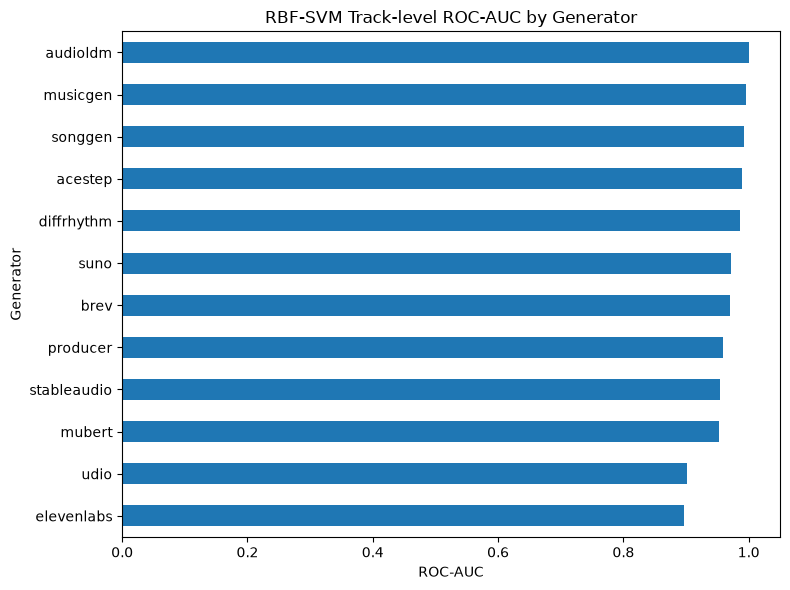

In [7]:
plot_df = svm_track_generator.sort_values("roc_auc")

ax = plot_df.set_index("generator")["roc_auc"].plot(
    kind="barh",
    figsize=(8, 6),
    title="RBF-SVM Track-level ROC-AUC by Generator",
)

ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Generator")

plt.tight_layout()
plt.show()

## 7. Generator별 FAKE Miss Rate

`fake_miss_rate`는 해당 generator가 만든 FAKE track 중
REAL로 잘못 판정한 비율이다.

낮을수록 좋다.

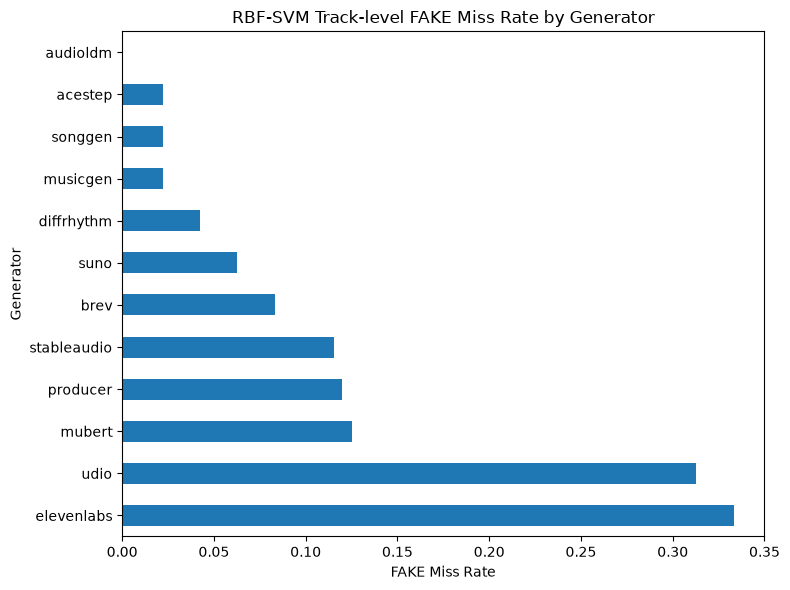

In [8]:
# Generator별 FAKE Miss Rate
plot_df = svm_track_generator.sort_values("fake_miss_rate", ascending=False)

ax = plot_df.set_index("generator")["fake_miss_rate"].plot(
    kind="barh",
    figsize=(8, 6),
    title="RBF-SVM Track-level FAKE Miss Rate by Generator",
)

ax.set_xlabel("FAKE Miss Rate")
ax.set_ylabel("Generator")

plt.tight_layout()
plt.show()

## 8. 가장 쉬운 / 어려운 Generator 확인

In [9]:
# 가장 쉬운 / 어려운 Generator 확인
print("===== BEST GENERATORS BY ROC-AUC =====")
display(
    svm_track_generator[
        [
            "generator",
            "n_fake",
            "roc_auc",
            "eer",
            "fake_miss_rate",
        ]
    ]
    .sort_values("roc_auc", ascending=False)
    .head(5)
    .round(4)
)

print("===== HARDEST GENERATORS BY ROC-AUC =====")
display(
    svm_track_generator[
        [
            "generator",
            "n_fake",
            "roc_auc",
            "eer",
            "fake_miss_rate",
        ]
    ]
    .sort_values("roc_auc", ascending=True)
    .head(5)
    .round(4)
)

print("===== HIGHEST FAKE MISS RATE =====")
display(
    svm_track_generator[
        [
            "generator",
            "n_fake",
            "roc_auc",
            "eer",
            "fake_miss_rate",
        ]
    ]
    .sort_values("fake_miss_rate", ascending=False)
    .head(5)
    .round(4)
)

===== BEST GENERATORS BY ROC-AUC =====


,generator,n_fake,roc_auc,eer,fake_miss_rate
0,audioldm,45,1.0000,0.0000,0.0000
1,musicgen,45,0.9951,0.0556,0.0222
2,songgen,45,0.9921,0.0222,0.0222
3,acestep,45,0.9886,0.0556,0.0222
4,diffrhythm,47,0.9863,0.0759,0.0426


===== HARDEST GENERATORS BY ROC-AUC =====


,generator,n_fake,roc_auc,eer,fake_miss_rate
11,elevenlabs,48,0.8968,0.2042,0.3333
10,udio,48,0.9014,0.2042,0.3125
9,mubert,24,0.9528,0.1611,0.1250
8,stableaudio,26,0.9538,0.1244,0.1154
7,producer,25,0.9591,0.1578,0.1200


===== HIGHEST FAKE MISS RATE =====


,generator,n_fake,roc_auc,eer,fake_miss_rate
11,elevenlabs,48,0.8968,0.2042,0.3333
10,udio,48,0.9014,0.2042,0.3125
9,mubert,24,0.9528,0.1611,0.1250
7,producer,25,0.9591,0.1578,0.1200
8,stableaudio,26,0.9538,0.1244,0.1154


## 9. LR vs RBF-SVM Generator별 Track ROC-AUC 비교

In [10]:
# LR vs RBF-SVM Generator별 Track ROC-AUC 비교
track_gen_compare = generator_results[generator_results["level"] == "track"].pivot(
    index="generator",
    columns="model",
    values="roc_auc",
)

track_gen_compare["SVM_minus_LR"] = (
    track_gen_compare["RBF-SVM"] - track_gen_compare["LogisticRegression"]
)

display(track_gen_compare.sort_values("SVM_minus_LR", ascending=False).round(4))

model,LogisticRegression,RBF-SVM,SVM_minus_LR
generator,,,
mubert,0.8398,0.9528,0.1130
musicgen,0.9185,0.9951,0.0765
diffrhythm,0.9243,0.9863,0.0619
suno,0.9227,0.9722,0.0495
acestep,0.9393,0.9886,0.0494
udio,0.8579,0.9014,0.0435
brev,0.9278,0.9694,0.0417
stableaudio,0.9188,0.9538,0.0350
elevenlabs,0.8630,0.8968,0.0338


# Part B. Genre별 성능

## 10. Genre별 평가

각 장르 내부의 REAL + FAKE Test 데이터를 사용한다.

예:

```text
Rock REAL
+
Rock FAKE
→ Rock 성능
```

Threshold는 전체 Validation에서 정한 global threshold를 그대로 사용한다.

In [11]:
# Genre별 평가
def genre_analysis(
    pred_df,
    model_name,
    level,
    score_col,
):
    fixed_threshold = THRESHOLDS[(model_name, level)]

    rows = []

    for genre in sorted(pred_df["genre"].dropna().unique()):
        subgroup = pred_df[pred_df["genre"] == genre].copy()

        metrics = evaluate_subgroup(
            subgroup["label_id"],
            subgroup[score_col],
            fixed_threshold,
        )

        if metrics is None:
            continue

        rows.append(
            {
                "model": model_name,
                "level": level,
                "genre": genre,
                **metrics,
            }
        )

    return pd.DataFrame(rows)


genre_results = pd.concat(
    [
        genre_analysis(
            segment_pred,
            "LogisticRegression",
            "segment",
            "lr_score",
        ),
        genre_analysis(
            track_pred,
            "LogisticRegression",
            "track",
            "lr_score",
        ),
        genre_analysis(
            segment_pred,
            "RBF-SVM",
            "segment",
            "svm_score",
        ),
        genre_analysis(
            track_pred,
            "RBF-SVM",
            "track",
            "svm_score",
        ),
    ],
    ignore_index=True,
)

display(genre_results.head())

,model,level,genre,n_total,n_real,n_fake,roc_auc,pr_auc,eer,fixed_threshold,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate,tn,fp,fn,tp
0,LogisticRegression,segment,Electronic,537,54,483,0.839161,0.976512,0.222912,0.666339,0.734127,0.662519,0.388889,0.142857,33,21,69,414
1,LogisticRegression,segment,Pop,413,30,383,0.897389,0.990570,0.157746,0.666339,0.836728,0.643966,0.133333,0.193211,26,4,74,309
2,LogisticRegression,segment,Rock,622,51,571,0.918512,0.991485,0.151987,0.666339,0.837506,0.676980,0.156863,0.168126,43,8,96,475
3,LogisticRegression,track,Electronic,185,18,167,0.881570,0.984183,0.227878,0.605935,0.791417,0.742052,0.333333,0.083832,12,6,14,153
4,LogisticRegression,track,Pop,141,10,131,0.961069,0.996878,0.069084,0.605935,0.885115,0.713415,0.100000,0.129771,9,1,17,114


## 11. RBF-SVM Track-level Genre 성능

In [12]:
# RBF-SVM Track-level Genre 성능
svm_track_genre = genre_results[
    (genre_results["model"] == "RBF-SVM") & (genre_results["level"] == "track")
].sort_values("roc_auc", ascending=False)

display(
    svm_track_genre[
        [
            "genre",
            "n_total",
            "n_real",
            "n_fake",
            "roc_auc",
            "eer",
            "balanced_accuracy",
            "macro_f1",
            "real_fpr",
            "fake_miss_rate",
        ]
    ].round(4)
)

,genre,n_total,n_real,n_fake,roc_auc,eer,balanced_accuracy,macro_f1,real_fpr,fake_miss_rate
10,Pop,141,10,131,0.9802,0.1263,0.8966,0.7426,0.1000,0.1069
11,Rock,213,17,196,0.9691,0.1609,0.8672,0.7034,0.1176,0.1480
9,Electronic,185,18,167,0.9687,0.1274,0.8619,0.8217,0.2222,0.0539


## 12. Genre별 ROC-AUC 비교

In [13]:
# Genre별 ROC-AUC 비교
genre_auc_compare = genre_results[genre_results["level"] == "track"].pivot(
    index="genre",
    columns="model",
    values="roc_auc",
)

genre_auc_compare["SVM_minus_LR"] = (
    genre_auc_compare["RBF-SVM"] - genre_auc_compare["LogisticRegression"]
)

display(genre_auc_compare.round(4))

model,LogisticRegression,RBF-SVM,SVM_minus_LR
genre,,,
Electronic,0.8816,0.9687,0.0872
Pop,0.9611,0.9802,0.0191
Rock,0.9496,0.9691,0.0195


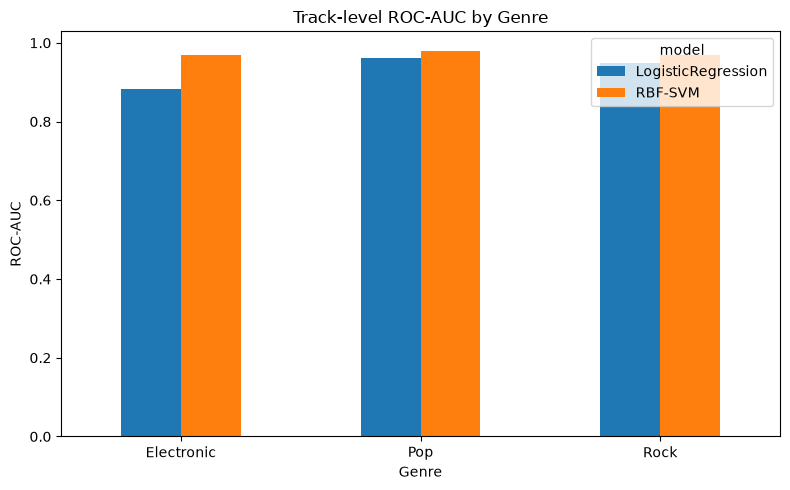

In [14]:
# Genre별 ROC-AUC 비교
ax = (
    genre_results[genre_results["level"] == "track"]
    .pivot(
        index="genre",
        columns="model",
        values="roc_auc",
    )
    .plot(
        kind="bar",
        figsize=(8, 5),
        title="Track-level ROC-AUC by Genre",
        rot=0,
    )
)

ax.set_ylabel("ROC-AUC")
ax.set_xlabel("Genre")

plt.tight_layout()
plt.show()

## 13. Genre별 오류율 비교

REAL FPR과 FAKE Miss Rate를 함께 확인한다.

,real_fpr,fake_miss_rate
genre,,
Pop,0.1000,0.1069
Rock,0.1176,0.1480
Electronic,0.2222,0.0539


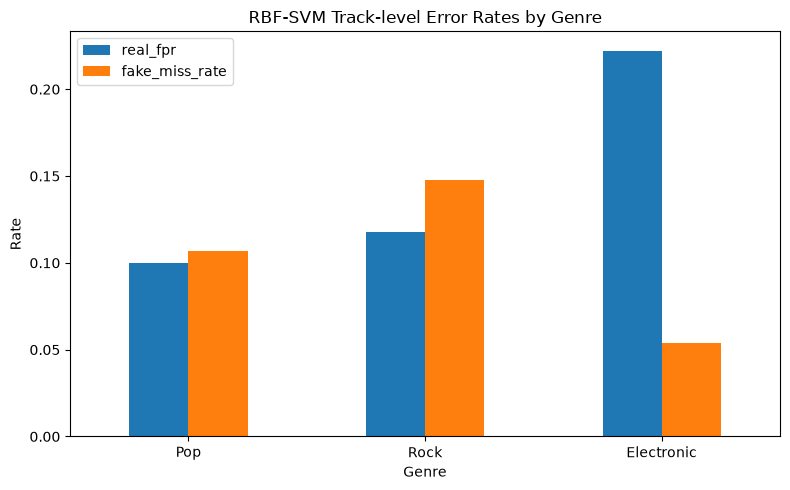

In [15]:
# Genre별 오류율 비교
genre_error_compare = svm_track_genre[
    [
        "genre",
        "real_fpr",
        "fake_miss_rate",
    ]
].set_index("genre")

display(genre_error_compare.round(4))

ax = genre_error_compare.plot(
    kind="bar",
    figsize=(8, 5),
    title="RBF-SVM Track-level Error Rates by Genre",
    rot=0,
)

ax.set_ylabel("Rate")
ax.set_xlabel("Genre")

plt.tight_layout()
plt.show()

# Part C. 추가 해석을 위한 분포 확인

## 14. Generator별 Test FAKE Track 수 확인

generator별 성능을 비교할 때 sample 수가 크게 다르면
작은 subgroup의 ROC-AUC / EER가 더 불안정할 수 있다.

따라서 반드시 `n_fake`를 함께 본다.

In [16]:
# Generator별 Test FAKE Track 수 확인
generator_sample_size = svm_track_generator[
    [
        "generator",
        "n_fake",
        "roc_auc",
        "eer",
        "fake_miss_rate",
    ]
].sort_values("n_fake", ascending=False)

display(generator_sample_size.round(4))

,generator,n_fake,roc_auc,eer,fake_miss_rate
5,suno,48,0.9722,0.0750,0.0625
6,brev,48,0.9694,0.1187,0.0833
10,udio,48,0.9014,0.2042,0.3125
11,elevenlabs,48,0.8968,0.2042,0.3333
4,diffrhythm,47,0.9863,0.0759,0.0426
0,audioldm,45,1.0000,0.0000,0.0000
1,musicgen,45,0.9951,0.0556,0.0222
2,songgen,45,0.9921,0.0222,0.0222
3,acestep,45,0.9886,0.0556,0.0222
8,stableaudio,26,0.9538,0.1244,0.1154


## 15. Test Generator Coverage와 연결해서 보기

현재 Test set에서 generator별 FAKE track 수를 확인해
전체 데이터 coverage 차이가 subgroup 결과에 미치는 영향을 참고한다.

In [17]:
# Test Generator Coverage와 연결해서 보기
test_fake_tracks = track_pred[track_pred["label"] == "FAKE"]

test_generator_coverage = (
    test_fake_tracks.groupby("generator")
    .agg(
        test_fake_tracks=("track_sample_id", "nunique"),
        test_original_audio=("original_audio", "nunique"),
    )
    .sort_values("test_original_audio", ascending=False)
)

display(test_generator_coverage)

,test_fake_tracks,test_original_audio
generator,,
acestep,45,45
audioldm,45,45
diffrhythm,47,45
musicgen,45,45
songgen,45,45
stableaudio,26,26
brev,48,24
elevenlabs,48,24
mubert,24,24


## 16. Generator별 결과 저장

In [18]:
generator_results.to_csv(
    OUTPUT_DIR / "generator_metrics_all.csv",
    index=False,
    encoding="utf-8-sig",
)

svm_track_generator.to_csv(
    OUTPUT_DIR / "rbf_svm_track_generator_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

track_gen_compare.to_csv(
    OUTPUT_DIR / "track_generator_auc_model_comparison.csv",
    encoding="utf-8-sig",
)

print("Saved generator analysis files.")

Saved generator analysis files.


## 17. Genre별 결과 저장

In [19]:
genre_results.to_csv(
    OUTPUT_DIR / "genre_metrics_all.csv",
    index=False,
    encoding="utf-8-sig",
)

svm_track_genre.to_csv(
    OUTPUT_DIR / "rbf_svm_track_genre_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)

genre_auc_compare.to_csv(
    OUTPUT_DIR / "track_genre_auc_model_comparison.csv",
    encoding="utf-8-sig",
)

print("Saved genre analysis files.")

Saved genre analysis files.


## 18. 최종 Subgroup QC

In [20]:
# 최종 Subgroup QC
qc_summary = pd.DataFrame(
    {
        "check": [
            "segment_test_rows",
            "track_test_rows",
            "segment_generators",
            "track_generators",
            "genres",
            "generator_result_rows",
            "genre_result_rows",
            "generator_nan_roc_auc",
            "genre_nan_roc_auc",
        ],
        "value": [
            len(segment_pred),
            len(track_pred),
            segment_pred.loc[segment_pred["label"] == "FAKE", "generator"].nunique(),
            track_pred.loc[track_pred["label"] == "FAKE", "generator"].nunique(),
            track_pred["genre"].nunique(),
            len(generator_results),
            len(genre_results),
            int(generator_results["roc_auc"].isna().sum()),
            int(genre_results["roc_auc"].isna().sum()),
        ],
    }
)

display(qc_summary)

subgroup_qc_pass = (
    len(segment_pred) == 1572
    and track_pred["track_sample_id"].nunique() == len(track_pred)
    and segment_pred.loc[segment_pred["label"] == "FAKE", "generator"].nunique() == 12
    and track_pred.loc[track_pred["label"] == "FAKE", "generator"].nunique() == 12
    and track_pred["genre"].nunique() == 3
    and generator_results["roc_auc"].isna().sum() == 0
    and genre_results["roc_auc"].isna().sum() == 0
)

print("===== FINAL RESULT =====")
print("Subgroup Analysis Core QC PASS:", subgroup_qc_pass)

,check,value
0,segment_test_rows,1572
1,track_test_rows,539
2,segment_generators,12
3,track_generators,12
4,genres,3
5,generator_result_rows,48
6,genre_result_rows,12
7,generator_nan_roc_auc,0
8,genre_nan_roc_auc,0


===== FINAL RESULT =====
Subgroup Analysis Core QC PASS: True


## 이어지는 기록

부분집합의 약점은 11번 unseen 생성기 실험에서 더 확인한다.

## 부분집합 결과

- 고정된 global Validation threshold로 generator별·genre별 Test 성능을 평가했다.
- RBF-SVM Track 기준 전체 Test ROC-AUC는 **0.9644**다.
- Generator별 성능 차이가 확인되어 전체 평균만으로 강건성을 판단할 수 없었다.
- MusicGen은 in-domain에서 강하지만 Udio 등 일부 generator는 상대적으로 어려워 unseen-generator 평가 대상으로 유지했다.
- 전체 subgroup 표를 `results/baseline/subgroup_analysis/`에 저장했다.